<h1>Train — ResNet-18 (baseline)</h1>

Trains and evaluates the ResNet-18 baseline classifier, then saves its results (`results_resnet18.pkl`) and weights (`{COMPONENT}_resnet18_cnn.pt`) to disk for the results notebook.

In [1]:
from wwtw_utils import *

Using device: cuda
Test set ID (derived from DATASET_ROOT): Fisantekraal
Classes found (4): ['Dysfunctional', 'Empty', 'Functional', 'Scum']
Train: 1814 | Val: 441 | Test: 252


## Define the model (Transfer Learning with ResNet-18)

In [2]:
model_resnet18 = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

num_ftrs = model_resnet18.fc.in_features
model_resnet18.fc = nn.Linear(num_ftrs, num_classes)  # no hidden layers — this one predates the tuning sweep

model_resnet18 = model_resnet18.to(device)

# ---------------------------------------------------------
# Loss and optimizer, with class weights for the imbalanced classes
# ---------------------------------------------------------
class_weights = make_class_weights(train_ds)
print("Applying class weights to loss function:")
for name, w in zip(class_names, class_weights.cpu().numpy()):
    print(f"  {name:<15s}: {w:.3f}")

criterion_resnet18 = nn.CrossEntropyLoss(weight=class_weights)
optimizer_resnet18 = optim.Adam(model_resnet18.parameters(), lr=5e-4, weight_decay=WEIGHT_DECAY)

# mode='min' because we want to minimize loss; factor=0.5 halves the LR when
# triggered; patience=3 waits 3 epochs with no improvement before reducing it
scheduler_resnet18 = ReduceLROnPlateau(optimizer_resnet18, mode='min', factor=0.5, patience=3)

Applying class weights to loss function:
  Dysfunctional  : 1.501
  Empty          : 1.627
  Functional     : 0.448
  Scum           : 0.425


## Train, then plot training curves

[ResNet-18] Epoch   1/100 | LR: 5.00e-04 | train loss 0.8910 acc 0.626 | val loss 0.5781 acc 0.748 *


[ResNet-18] Epoch   2/100 | LR: 5.00e-04 | train loss 0.5952 acc 0.734 | val loss 0.6003 acc 0.746


[ResNet-18] Epoch   3/100 | LR: 5.00e-04 | train loss 0.4934 acc 0.782 | val loss 1.0431 acc 0.692


[ResNet-18] Epoch   4/100 | LR: 5.00e-04 | train loss 0.4648 acc 0.794 | val loss 0.4581 acc 0.803 *


[ResNet-18] Epoch   5/100 | LR: 5.00e-04 | train loss 0.4094 acc 0.809 | val loss 0.4085 acc 0.834 *


...

[ResNet-18] Epoch  25/100 | LR: 1.25e-04 | train loss 0.0538 acc 0.975 | val loss 0.3817 acc 0.873


[ResNet-18] Epoch  26/100 | LR: 1.25e-04 | train loss 0.0406 acc 0.984 | val loss 0.3764 acc 0.893


[ResNet-18] Epoch  27/100 | LR: 6.25e-05 | train loss 0.0468 acc 0.978 | val loss 0.4061 acc 0.880


[ResNet-18] Epoch  28/100 | LR: 6.25e-05 | train loss 0.0270 acc 0.989 | val loss 0.3930 acc 0.882


[ResNet-18] Epoch  29/100 | LR: 6.25e-05 | train loss 0.0269 acc 0.990 | val loss 0.3851 acc 0.891

[ResNet-18] No val loss improvement for 10 epochs — stopping early at epoch 29.

[ResNet-18] Restored best checkpoint (val loss = 0.3171)


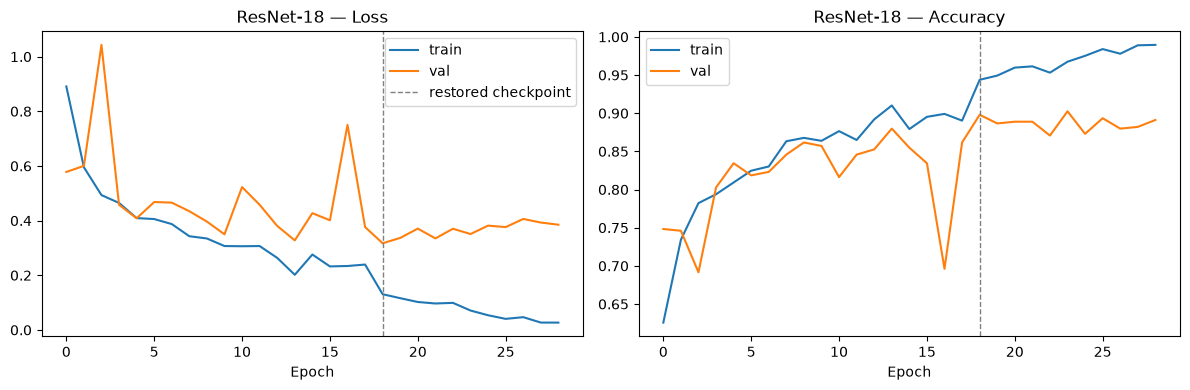

In [3]:
history_resnet18 = train_model(
    model_resnet18, train_loader, val_loader, optimizer_resnet18, scheduler_resnet18,
    criterion_resnet18, EPOCHS, EARLY_STOP_PATIENCE, "ResNet-18",
)
plot_training_curves(history_resnet18, "ResNet-18")

## Evaluate on the test set

[ResNet-18] Test accuracy: 0.770


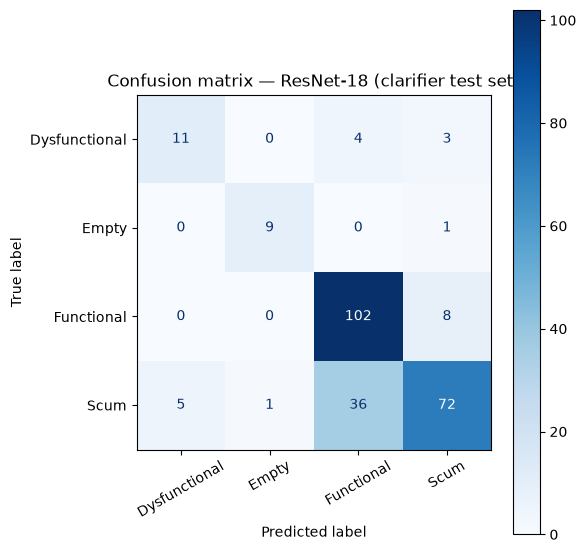

               precision    recall  f1-score   support

Dysfunctional      0.688     0.611     0.647        18
        Empty      0.900     0.900     0.900        10
   Functional      0.718     0.927     0.810       110
         Scum      0.857     0.632     0.727       114

     accuracy                          0.770       252
    macro avg      0.791     0.767     0.771       252
 weighted avg      0.786     0.770     0.764       252



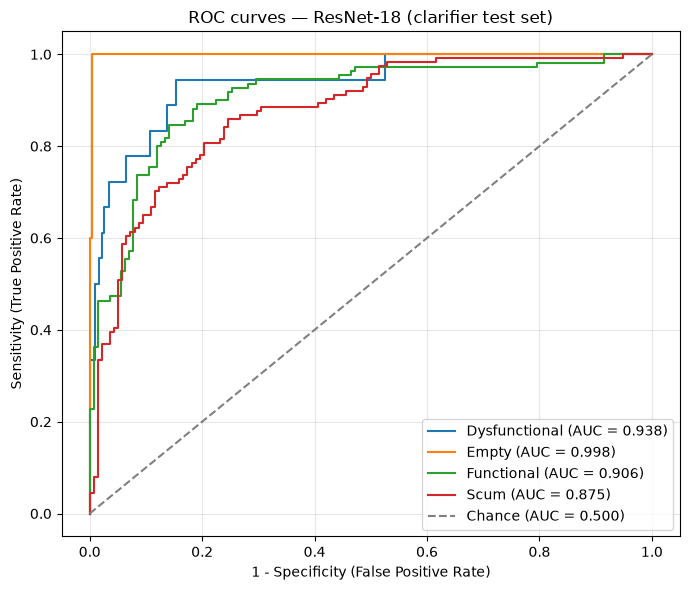

AUC (area under ROC curve) per class:
  Dysfunctional  : 0.938
  Empty          : 0.998
  Functional     : 0.906
  Scum           : 0.875

Mean AUC (over 4/4 classes with test examples): 0.929


(np.float64(0.7698412698412699),
 {'Dysfunctional': 0.9382716049382716,
  'Empty': 0.9983471074380166,
  'Functional': 0.9058258642765684,
  'Scum': 0.8746503941011949})

In [4]:
evaluate_and_record(
    model_resnet18, test_loader, "ResNet-18", history_resnet18,
    img_size=IMG_TARGET_SIZE, hidden_layers=0, neurons=None,
)

## Save results + model weights to disk

This is the step the results notebook depends on — it pickles the metrics/history and saves the model state dict so nothing needs to be kept in memory or re-trained.

In [5]:
save_result("ResNet-18", "resnet18")

Saved results to ../results/results_clarifier_resnet18_Fisantekraal.pkl


Saved model weights to ../models/clarifier_resnet18_cnn.pt
